<a href="https://www.kaggle.com/code/sonawanelalitsunil/social-media-engagement-analysis-ml-50?scriptVersionId=248597160" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/social-media-engagement/social_media_engagement1.csv


## Title : Social Media Engagement Analysis

## ✅ Detailed Description:
This project explores patterns in social media engagement using real post data across various platforms. By analyzing features like post type, platform, time of posting, and user interactions (likes, comments, shares), the study uncovers how different factors influence audience response. We apply data preprocessing, visualizations, and machine learning models to predict sentiment and engagement trends. The goal is to derive actionable insights that can help optimize content strategy and improve reach and interaction across platforms.



## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/social-media-engagement/social_media_engagement1.csv')

In [3]:
df.head()

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score
0,1,Facebook,image,8/17/2023 14:45,2121,474,628,Thursday,positive
1,2,Facebook,carousel,5/14/2023 0:45,3660,432,694,Sunday,neutral
2,3,Instagram,poll,2/21/2023 16:15,4955,408,688,Tuesday,negative
3,4,Twitter,image,11/16/2023 0:45,1183,90,187,Thursday,negative
4,5,Twitter,video,5/23/2023 0:30,3499,247,286,Tuesday,positive


In [4]:
df.tail()

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score
95,96,Instagram,carousel,7/12/2023 17:45,36,294,911,Wednesday,positive
96,97,Twitter,video,10/27/2023 23:45,314,108,458,Friday,neutral
97,98,Twitter,text,8/5/2023 8:45,229,179,38,Saturday,positive
98,99,Instagram,poll,12/29/2023 12:15,5000,500,204,Friday,positive
99,100,Instagram,image,6/6/2023 21:00,4483,357,25,Tuesday,neutral


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   post_id          100 non-null    int64 
 1   platform         100 non-null    object
 2   post_type        100 non-null    object
 3   post_time        100 non-null    object
 4   likes            100 non-null    int64 
 5   comments         100 non-null    int64 
 6   shares           100 non-null    int64 
 7   post_day         100 non-null    object
 8   sentiment_score  100 non-null    object
dtypes: int64(4), object(5)
memory usage: 7.2+ KB


In [6]:
df.describe()

,post_id,likes,comments,shares
count,100.000000,100.000000,100.00000,100.000000
mean,50.500000,2381.810000,202.66000,415.650000
std,29.011492,1632.573284,138.84067,283.877601
min,1.000000,15.000000,10.00000,16.000000
25%,25.750000,895.750000,89.75000,183.000000
50%,50.500000,2220.000000,171.00000,356.500000
75%,75.250000,3593.250000,299.00000,689.500000
max,100.000000,5000.000000,500.00000,993.000000


In [7]:
df.dtypes

post_id             int64
platform           object
post_type          object
post_time          object
likes               int64
comments            int64
shares              int64
post_day           object
sentiment_score    object
dtype: object

In [8]:
df.shape

(100, 9)

In [9]:
df.isnull().sum()

post_id            0
platform           0
post_type          0
post_time          0
likes              0
comments           0
shares             0
post_day           0
sentiment_score    0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.columns

Index(['post_id', 'platform', 'post_type', 'post_time', 'likes', 'comments',
       'shares', 'post_day', 'sentiment_score'],
      dtype='object')

## Data visualizations

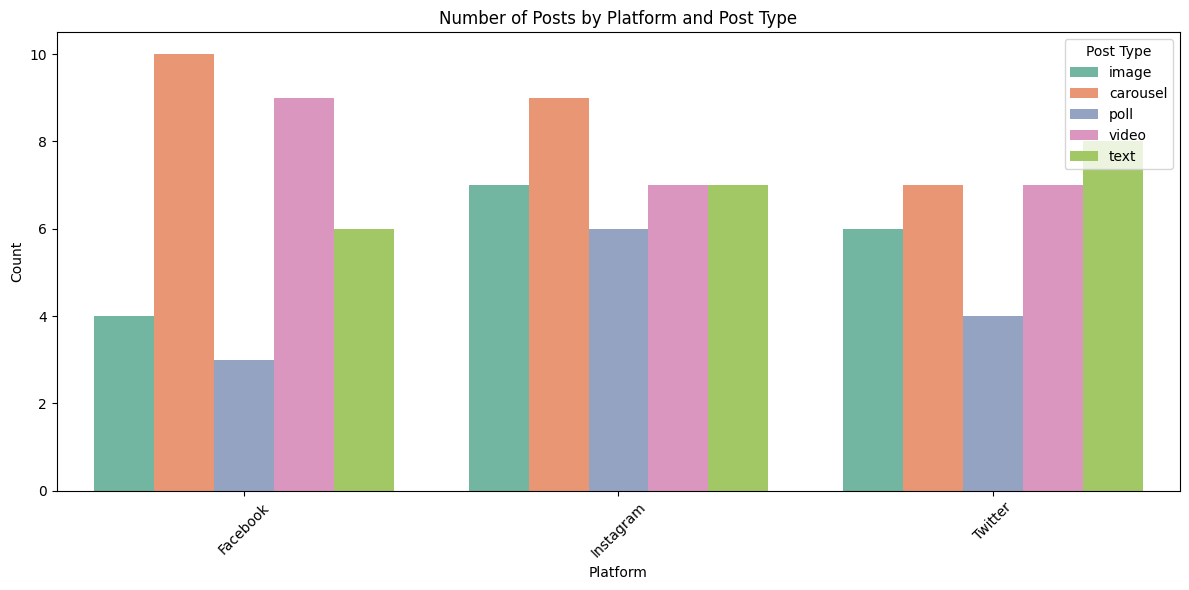

In [12]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='platform', hue='post_type', palette='Set2')
plt.title('Number of Posts by Platform and Post Type')
plt.xlabel('Platform')
plt.ylabel('Count')
plt.legend(title='Post Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


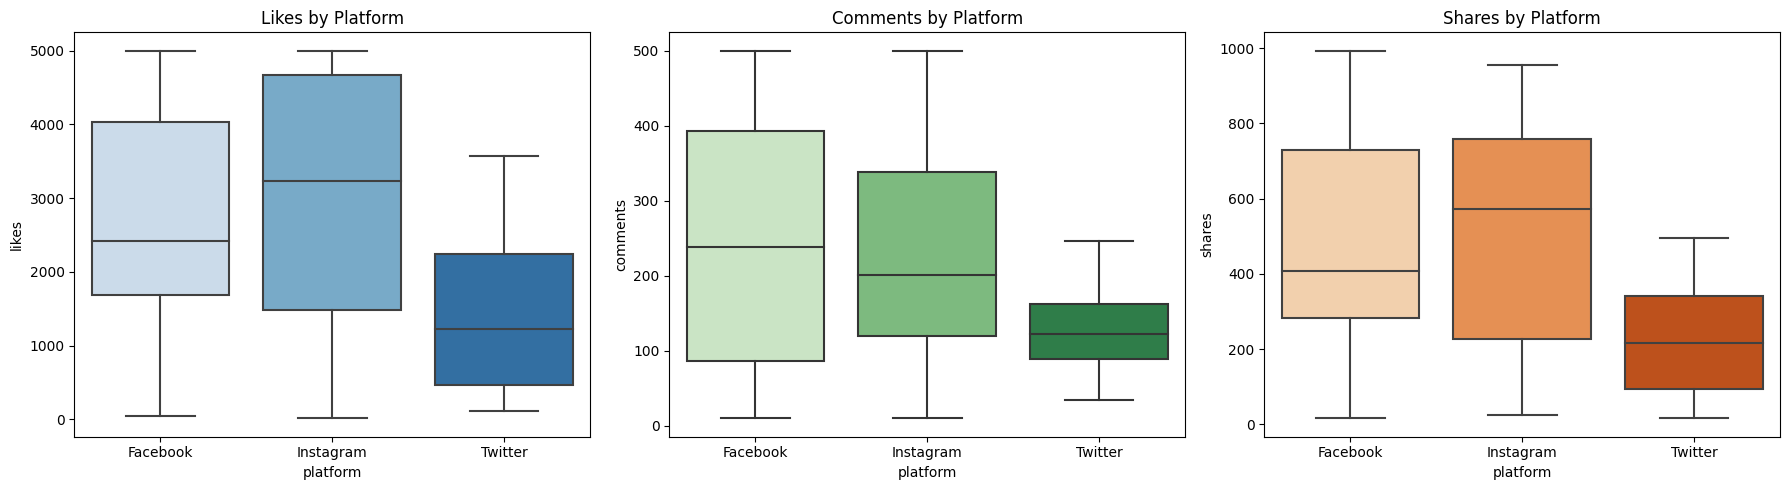

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, y='likes', x='platform', ax=axes[0], palette='Blues')
axes[0].set_title('Likes by Platform')

sns.boxplot(data=df, y='comments', x='platform', ax=axes[1], palette='Greens')
axes[1].set_title('Comments by Platform')

sns.boxplot(data=df, y='shares', x='platform', ax=axes[2], palette='Oranges')
axes[2].set_title('Shares by Platform')

plt.tight_layout()
plt.show()


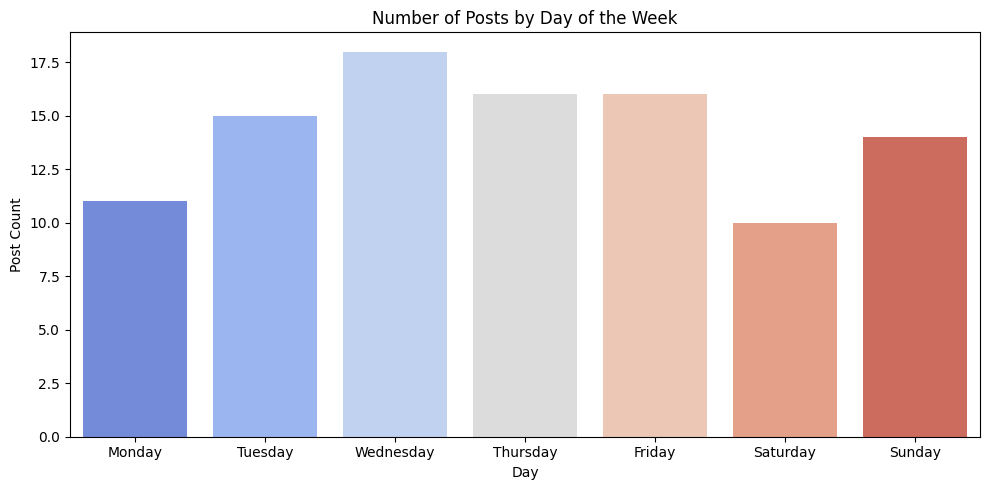

In [14]:
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='post_day', order=order, palette='coolwarm')
plt.title('Number of Posts by Day of the Week')
plt.xlabel('Day')
plt.ylabel('Post Count')
plt.tight_layout()
plt.show()


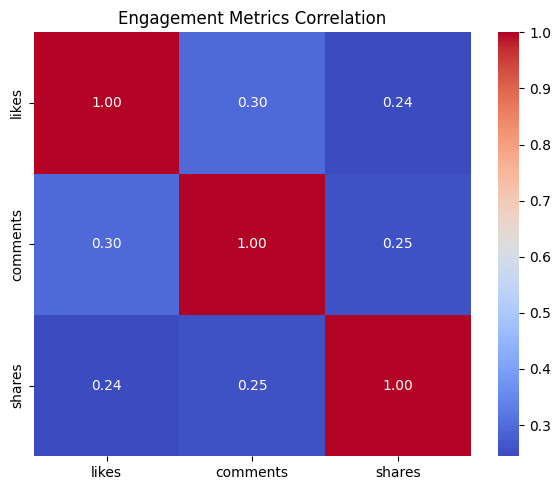

In [15]:
numeric_cols = ['likes', 'comments', 'shares']
plt.figure(figsize=(6, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Engagement Metrics Correlation')
plt.tight_layout()
plt.show()


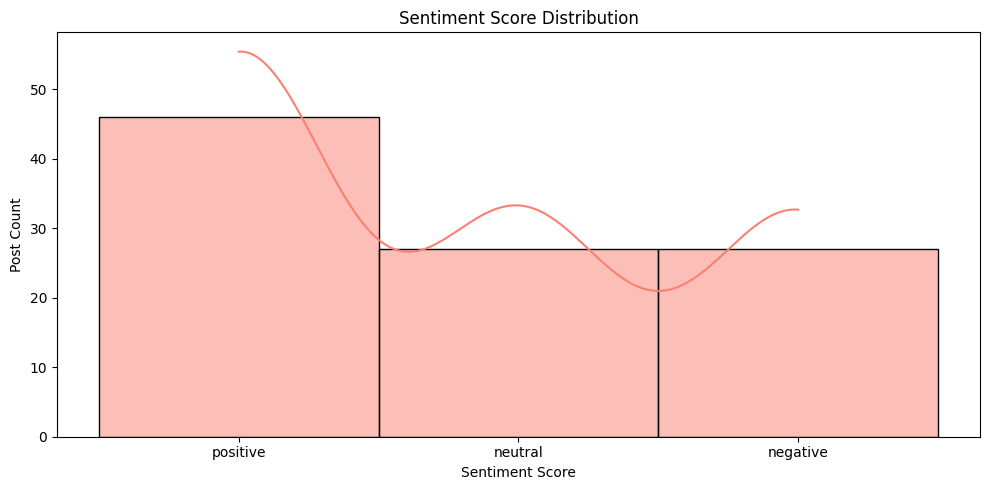

In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(df['sentiment_score'], kde=True, bins=30, color='salmon')
plt.title('Sentiment Score Distribution')
plt.xlabel('Sentiment Score')
plt.ylabel('Post Count')
plt.tight_layout()
plt.show()


In [17]:
df['post_time'] = pd.to_datetime(df['post_time'], errors='coerce')

# Step 2: Extract hour of the day
df['post_hour'] = df['post_time'].dt.hour

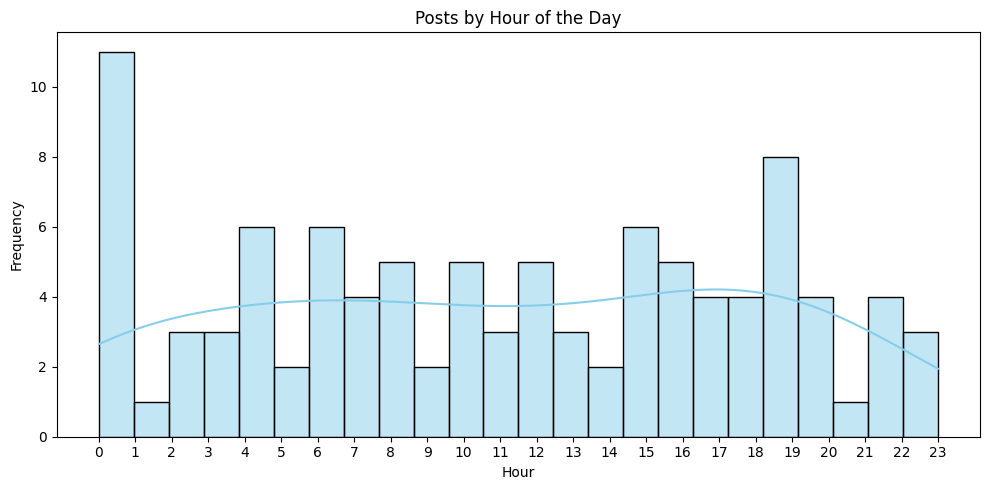

In [18]:
plt.figure(figsize=(10, 5))
sns.histplot(df['post_hour'], bins=24, kde=True, color='skyblue')
plt.title('Posts by Hour of the Day')
plt.xlabel('Hour')
plt.ylabel('Frequency')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


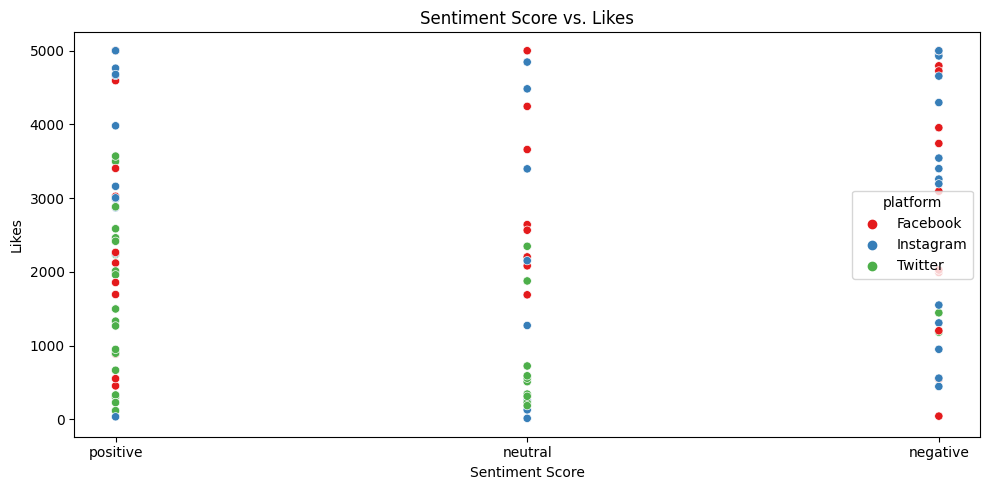

In [19]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='sentiment_score', y='likes', hue='platform', palette='Set1')
plt.title('Sentiment Score vs. Likes')
plt.xlabel('Sentiment Score')
plt.ylabel('Likes')
plt.tight_layout()
plt.show()


## Predictve modeling

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [21]:
# Sample cleanup
df['post_time'] = pd.to_datetime(df['post_time'], errors='coerce')
df['post_hour'] = df['post_time'].dt.hour
df['post_day'] = df['post_day'].astype(str)


In [22]:
# Drop irrelevant columns
df = df.drop(columns=['post_id', 'post_time'])

# Handle missing values
df = df.dropna()


In [23]:
# Encode categorical features
label_encoders = {}
categorical_cols = ['platform', 'post_type', 'post_day']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Encode target
target_le = LabelEncoder()
df['sentiment_score'] = target_le.fit_transform(df['sentiment_score'])

# Features and Target
X = df.drop(columns=['sentiment_score'])
y = df['sentiment_score']


In [24]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Support Vector Machine': SVC(),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

# Train and evaluate
accuracies = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    accuracies[name] = round(acc, 2)

# Show results
for model, acc in accuracies.items():
    print(f"{model}: {acc}% accuracy")

Logistic Regression: 45.0% accuracy
Random Forest: 45.0% accuracy
Decision Tree: 35.0% accuracy
Support Vector Machine: 50.0% accuracy
Naive Bayes: 50.0% accuracy
K-Nearest Neighbors: 30.0% accuracy


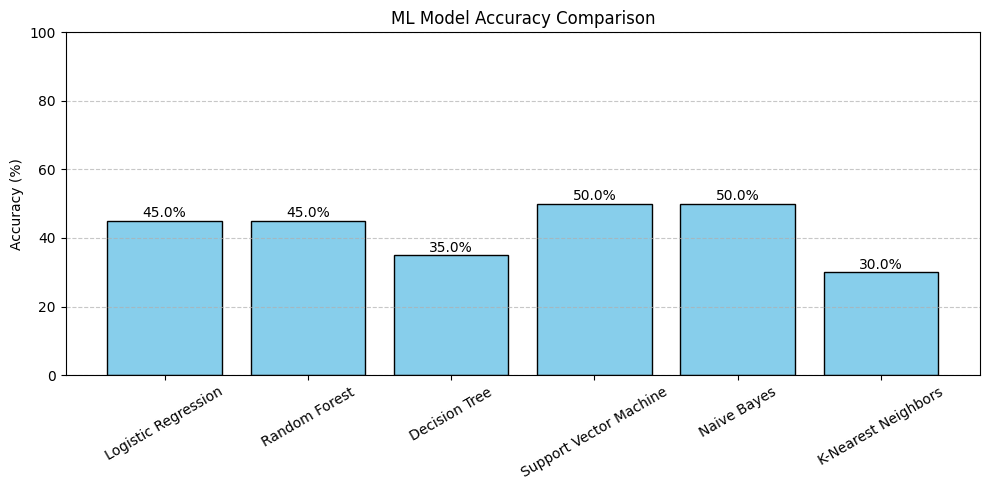

In [25]:
# Accuracy dictionary based on your results
accuracies = {
    'Logistic Regression': 45.0,
    'Random Forest': 45.0,
    'Decision Tree': 35.0,
    'Support Vector Machine': 50.0,
    'Naive Bayes': 50.0,
    'K-Nearest Neighbors': 30.0
}

# Plot
plt.figure(figsize=(10, 5))
bars = plt.bar(accuracies.keys(), accuracies.values(), color='skyblue', edgecolor='black')

# Add value labels on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', fontsize=10)

plt.ylabel('Accuracy (%)')
plt.title('ML Model Accuracy Comparison')
plt.xticks(rotation=30)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Thank you!!! pls upvote!!